In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from aaa_tps.systems.two_dimensional_double_wells import StandardDoubleWell

In [3]:
stdw = StandardDoubleWell(barrier=10, asymmetry=0)

stdw_E = stdw.energy_function
stdw_F = stdw.force_function

In [4]:
from aaa_tps.states.states import circular_state

stdw_state_A = circular_state(center=(-1,-1), axes=(1,2), angle=-0.25, radius=0.05) 
stdw_state_B = circular_state(center=(1,1), axes=(1,2), angle=-0.25, radius=0.05) 

In [5]:
x_values = np.linspace(-1.6, 1.6, 100)
y_values = np.linspace(-2.6, 2.6, 100)

x_grid, y_grid = np.meshgrid(x_values, y_values)

U = np.zeros((len(x_values), len(y_values)))
Fx = np.zeros((len(x_values), len(y_values)))
Fy = np.zeros((len(x_values), len(y_values)))

in_state_A = np.zeros((len(x_values), len(y_values)))
in_state_B = np.zeros((len(x_values), len(y_values)))

for i in range(len(x_values)):
    for j in range(len(y_values)):

        U[i,j] = stdw_E(np.array([x_grid[i, j], y_grid[i, j]]))
        
        f = stdw_F(np.array([x_grid[i, j], y_grid[i, j]]))
        Fx[i,j] = f[0]
        Fy[i,j] = f[1]

        in_state_A[i,j] = stdw_state_A.is_in_state(np.array([x_grid[i, j], y_grid[i, j]]))
        in_state_B[i,j] = stdw_state_B.is_in_state(np.array([x_grid[i, j], y_grid[i, j]]))

nsample = 1
x_grid_sub = x_grid[::nsample, ::nsample]
y_grid_sub = y_grid[::nsample, ::nsample]
Fx_sub = Fx[::nsample, ::nsample]
Fy_sub = Fy[::nsample, ::nsample]

Fnorm = np.sqrt(Fx_sub**2 + Fy_sub**2)
fx = Fx_sub / (Fnorm + 1e-12)
fy = Fy_sub / (Fnorm + 1e-12)

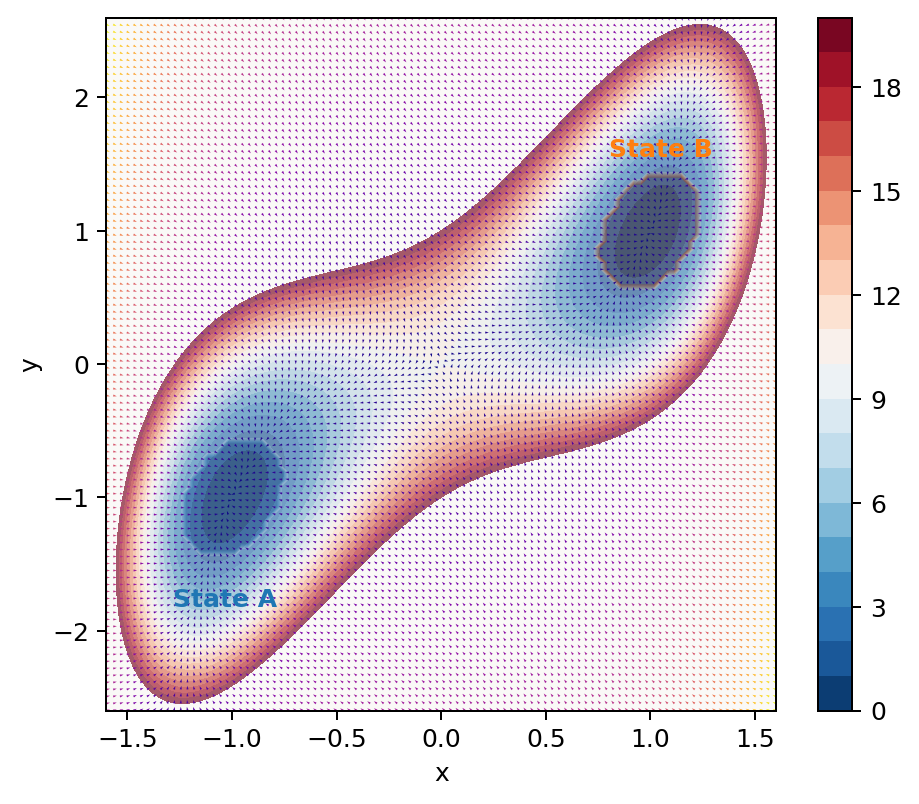

In [6]:
fig, ax = plt.subplots(1, figsize=(6,5), dpi=180)

cont = ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.2)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.2)
quiv = ax.quiver(x_grid_sub, y_grid_sub, fx, fy, Fnorm, cmap='plasma')
ax.text(0.1, 0.15, r"State A", fontweight='bold', transform=ax.transAxes, c="C0")
ax.text(0.75, 0.8, r"State B", fontweight='bold', transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.colorbar(cont, ax=ax)

plt.show()

In [7]:
inputdir_ref = "./reference/twoway_shooting/stdw/Uniform"

inputdir_2w = "./output/twoway_shooting/stdw/Gaussian"
inputdir_1w = "./output/oneway_shooting/stdw/Gaussian"
inputdir_ARA_TPS_Unif = "./output/ARA-TPS/stdw/Uniform"
inputdir_ARA_TPS_Gaus = "./output/ARA-TPS/stdw/Gaussian"
inputdir_AAA_TPS_Unif = "./output/AAA-TPS/stdw/Uniform"
inputdir_AAA_TPS_Gaus = "./output/AAA-TPS/stdw/Gaussian"

In [8]:
n_replicas_ref = 250
n_replicas = 5

In [9]:
lengths_ref = []
lengths_2w = []
lengths_1w = []
lengths_ARA_TPS_Unif = []
lengths_ARA_TPS_Gaus = []
lengths_AAA_TPS_Unif = []
lengths_AAA_TPS_Gaus = []

weights_lengths_AAA_TPS_Unif = []
weights_lengths_AAA_TPS_Gaus = []

weights_norm_lengths_AAA_TPS_Unif = []
weights_norm_lengths_AAA_TPS_Gaus = []

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

# for replica in range(n_replicas_ref):
    
#     length_ref_fn = os.path.join(inputdir_ref, f"R_{replica:04d}", f"lengths_2w.txt")
#     lengths_ref.append(np.loadtxt(length_ref_fn))


for replica in range(starting_replica, ending_replica, replica_stride):
    
    length_2w_fn = os.path.join(inputdir_2w, f"R_{replica:04d}", f"lengths_2w.txt")
    lengths_2w.append(np.loadtxt(length_2w_fn))

    length_1w_fn = os.path.join(inputdir_1w, f"R_{replica:04d}", f"lengths_1w.txt")
    lengths_1w.append(np.loadtxt(length_1w_fn))

    length_ARA_TPS_Unif_fn = os.path.join(inputdir_ARA_TPS_Unif, f"R_{replica:04d}", f"lengths_ARA-TPS.txt")
    lengths_ARA_TPS_Unif.append(np.loadtxt(length_ARA_TPS_Unif_fn))

    length_ARA_TPS_Gaus_fn = os.path.join(inputdir_ARA_TPS_Gaus, f"R_{replica:04d}", f"lengths_ARA-TPS.txt")
    lengths_ARA_TPS_Gaus.append(np.loadtxt(length_ARA_TPS_Gaus_fn))

    length_AAA_TPS_Unif_fn = os.path.join(inputdir_AAA_TPS_Unif, f"R_{replica:04d}", f"lengths_AAA-TPS.txt")
    lengths_AAA_TPS_Unif.append(np.loadtxt(length_AAA_TPS_Unif_fn))

    weights_lengths_AAA_TPS_Unif_fn = os.path.join(inputdir_AAA_TPS_Unif, f"R_{replica:04d}", f"acc_w_len_AAA-TPS.txt")
    weights_lengths_AAA_TPS_Unif.append(np.loadtxt(weights_lengths_AAA_TPS_Unif_fn))
    weights_norm_lengths_AAA_TPS_Unif.append(weights_lengths_AAA_TPS_Unif[replica]/weights_lengths_AAA_TPS_Unif[replica].sum())

    length_AAA_TPS_Gaus_fn = os.path.join(inputdir_AAA_TPS_Gaus, f"R_{replica:04d}", f"lengths_AAA-TPS.txt")
    lengths_AAA_TPS_Gaus.append(np.loadtxt(length_AAA_TPS_Gaus_fn))

    weights_lengths_AAA_TPS_Gaus_fn = os.path.join(inputdir_AAA_TPS_Gaus, f"R_{replica:04d}", f"acc_p_sel_norm_len_AAA-TPS.txt")
    weights_lengths_AAA_TPS_Gaus.append(1/np.loadtxt(weights_lengths_AAA_TPS_Gaus_fn))
    weights_norm_lengths_AAA_TPS_Gaus.append(weights_lengths_AAA_TPS_Gaus[replica]/weights_lengths_AAA_TPS_Gaus[replica].sum())

In [10]:
all_lengths = [lengths_ref, 
               lengths_2w, 
               lengths_1w, 
               lengths_ARA_TPS_Unif, 
               lengths_ARA_TPS_Gaus, 
               lengths_AAA_TPS_Unif, 
               lengths_AAA_TPS_Gaus,
               ]

max_length = max(num for lst in all_lengths for row in lst for num in row)

n_bins = 200
power = 11
bins = np.linspace(0, 1, n_bins) ** power * max_length

/tmp/ipykernel_113822/3014246675.py:42: RuntimeWarning: Mean of empty slice.
  hist_ref_avg = np.array(hist_ref).mean(axis=0)
/home/acoretti/Documents/Projects/AlwaysReactiveOneWayShooting/paper_AAA-TPS/conda_envs/aaa_tps/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


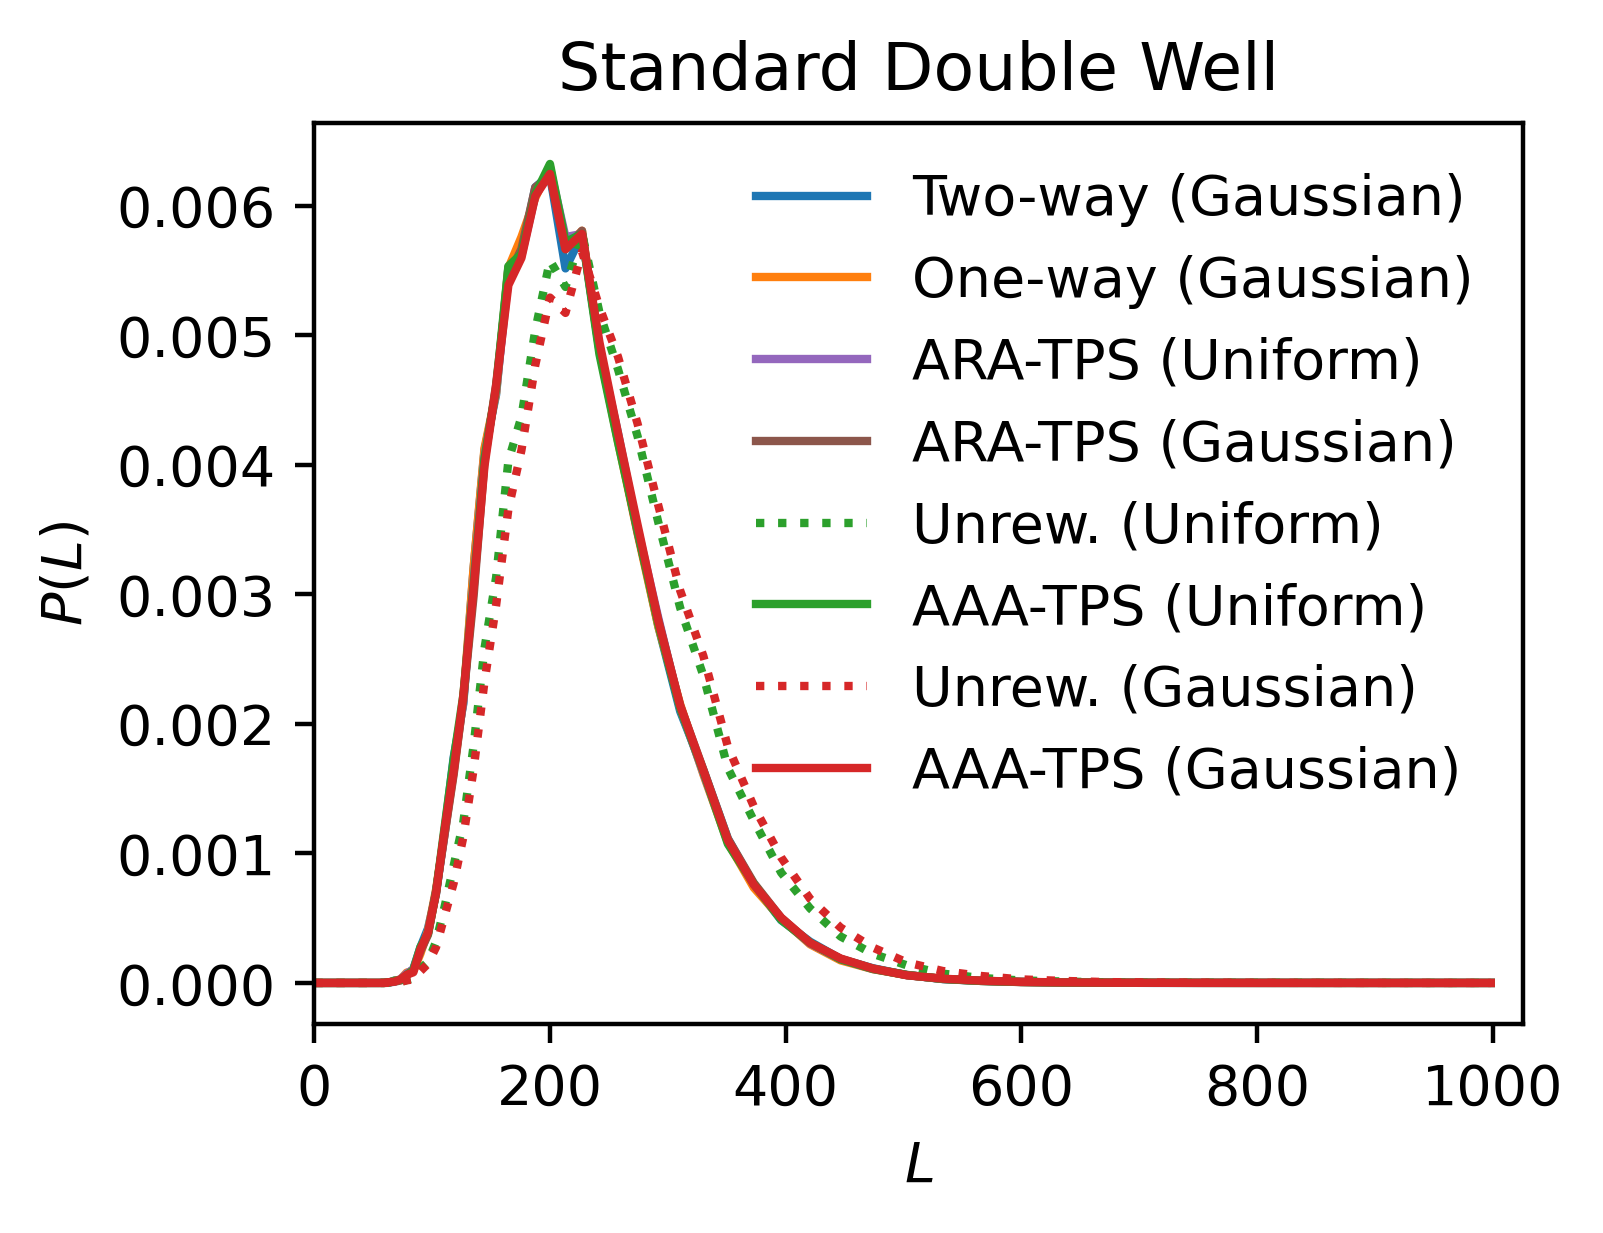

In [11]:
hist_ref = []
hist_2w = []
hist_1w = []
hist_ARA_TPS_Unif = []
hist_ARA_TPS_Gaus = []

hist_AAA_TPS_Unif = []
hist_AAA_TPS_Unif_Rw = []

hist_AAA_TPS_Gaus = []
hist_AAA_TPS_Gaus_Rw = []

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

# for replica in range(n_replicas_ref):    
#     vals_ref, _ = np.histogram(lengths_ref[replica], bins=bins, density=True)
#     hist_ref.append(vals_ref)    

for replica in range(starting_replica, ending_replica, replica_stride):    

    vals_2w, _ = np.histogram(lengths_2w[replica], bins=bins, density=True)
    hist_2w.append(vals_2w)
    vals_1w, _ = np.histogram(lengths_1w[replica], bins=bins, density=True)
    hist_1w.append(vals_1w)
    vals_ARA_TPS_Unif, _ = np.histogram(lengths_ARA_TPS_Unif[replica], bins=bins, density=True)
    hist_ARA_TPS_Unif.append(vals_ARA_TPS_Unif)
    vals_ARA_TPS_Gaus, _ = np.histogram(lengths_ARA_TPS_Gaus[replica], bins=bins, density=True)
    hist_ARA_TPS_Gaus.append(vals_ARA_TPS_Gaus)

    vals_AAA_TPS_Unif, _ = np.histogram(lengths_AAA_TPS_Unif[replica], bins=bins, density=True)
    hist_AAA_TPS_Unif.append(vals_AAA_TPS_Unif)
    vals_AAA_TPS_Unif_Rw, _ = np.histogram(lengths_AAA_TPS_Unif[replica], bins=bins, density=True, weights=weights_norm_lengths_AAA_TPS_Unif[replica])
    hist_AAA_TPS_Unif_Rw.append(vals_AAA_TPS_Unif_Rw)
    
    vals_AAA_TPS_Gaus, _ = np.histogram(lengths_AAA_TPS_Gaus[replica], bins=bins, density=True)
    hist_AAA_TPS_Gaus.append(vals_AAA_TPS_Gaus)
    vals_AAA_TPS_Gaus_Rw, _ = np.histogram(lengths_AAA_TPS_Gaus[replica], bins=bins, density=True, weights=weights_norm_lengths_AAA_TPS_Gaus[replica])
    hist_AAA_TPS_Gaus_Rw.append(vals_AAA_TPS_Gaus_Rw)

hist_ref_avg = np.array(hist_ref).mean(axis=0)
hist_2w_avg = np.array(hist_2w).mean(axis=0)
hist_1w_avg = np.array(hist_1w).mean(axis=0)
hist_ARA_TPS_Unif_avg = np.array(hist_ARA_TPS_Unif).mean(axis=0)
hist_ARA_TPS_Gaus_avg = np.array(hist_ARA_TPS_Gaus).mean(axis=0)
hist_AAA_TPS_Unif_avg = np.array(hist_AAA_TPS_Unif).mean(axis=0)
hist_AAA_TPS_Unif_Rw_avg = np.array(hist_AAA_TPS_Unif_Rw).mean(axis=0)
hist_AAA_TPS_Gaus_avg = np.array(hist_AAA_TPS_Gaus).mean(axis=0)
hist_AAA_TPS_Gaus_Rw_avg = np.array(hist_AAA_TPS_Gaus_Rw).mean(axis=0)

bin_centers = (bins[:-1] + bins[1:])/2

fig, ax = plt.subplots(1, figsize=(10 * 0.39, 7.5 * 0.39), dpi=400)

# ax.plot(bin_centers, hist_ref_avg, color='k', label="Reference")
ax.plot(bin_centers, hist_2w_avg, color='C0', label="Two-way (Gaussian)")
ax.plot(bin_centers, hist_1w_avg, color='C1', label="One-way (Gaussian)")
ax.plot(bin_centers, hist_ARA_TPS_Unif_avg, color='C4', label="ARA-TPS (Uniform)")
ax.plot(bin_centers, hist_ARA_TPS_Gaus_avg, color='C5', label="ARA-TPS (Gaussian)")
ax.plot(bin_centers, hist_AAA_TPS_Unif_avg, color='C2', ls=":", label="Unrew. (Uniform)")
ax.plot(bin_centers, hist_AAA_TPS_Unif_Rw_avg, color='C2', label="AAA-TPS (Uniform)")
ax.plot(bin_centers, hist_AAA_TPS_Gaus_avg, color='C3', ls=":", label="Unrew. (Gaussian)")
ax.plot(bin_centers, hist_AAA_TPS_Gaus_Rw_avg, color='C3', label="AAA-TPS (Gaussian)")

ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$P(L)$")
ax.set_xlim(0, max_length)

plt.title("Standard Double Well")
plt.legend(frameon=False, loc="upper right")
plt.show()

In [12]:
Hist_ref_avg = np.loadtxt(os.path.join(inputdir_ref, f'Hist_ref_avg.txt'))
His_ref_avg_norm = Hist_ref_avg/Hist_ref_avg.sum()

In [13]:
from tqdm import tqdm
from aaa_tps.utils.observables import padded_chunk_cumsum

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_2w = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_2w = []
all_sampled_points = []  # list to collect sampled points
total_points = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_2w, f"R_{replica:04d}", f'paths_2w.pkl'), 'rb') as f:
        trajectory_ensemble_2w = pickle.load(f)[::n_sample]
    
    n_trajectories = len(trajectory_ensemble_2w)

    force_eval_2w_fn = os.path.join(inputdir_2w, f"R_{replica:04d}", f"force_evaluations_2w.txt")
    force_eval_2w[rep_count] = np.loadtxt(force_eval_2w_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_2w[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        total_points += batch_points.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist

        # === Normalize accumulated histogram ===
        norm_hist_2w = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist_2w)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_2w.append(total_abs_diff)
    
    rep_count += 1

chunked_tot_force_eval_2w = padded_chunk_cumsum(force_eval_2w.flatten(), traj_step+10)
tot_force_eval_2w = np.sum(force_eval_2w, axis=-1)
per_tr_force_eval_2w = force_eval_2w.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_2w.mean(axis=0)} +- {np.std(tot_force_eval_2w, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_2w, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_2w.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_2w.mean(axis=0)} +- {np.std(per_tr_force_eval_2w, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_2w, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_2w.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_2w, "P_x_TP_conv_2w.txt"), np.c_[np.array(chunked_tot_force_eval_2w[1:]), np.array(abs_diff_sums_2w)])

100%|██████████| 99/99 [00:00<00:00, 187.89it/s]


Total Force Evaluations (average over replicas): 23457302.6 +- 11370.94348152342 -> D = 0.05%
Per Trial Average Force Evaluations: 234.57537175371755 +- 36.743792953463 -> D = 15.66%


In [14]:
from tqdm import tqdm

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_1w = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_1w = []
all_sampled_points = []  # list to collect sampled points
total_points = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_1w, f"R_{replica:04d}", f'paths_1w.pkl'), 'rb') as f:
        trajectory_ensemble_1w = pickle.load(f)[::n_sample]
    
    n_trajectories = len(trajectory_ensemble_1w)

    force_eval_1w_fn = os.path.join(inputdir_1w, f"R_{replica:04d}", f"force_evaluations_1w.txt")
    force_eval_1w[rep_count] = np.loadtxt(force_eval_1w_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_1w[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        total_points += batch_points.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist

        # === Normalize accumulated histogram ===
        norm_hist_1w = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist_1w)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_1w.append(total_abs_diff)
    
    rep_count += 1

chunked_tot_force_eval_1w = padded_chunk_cumsum(force_eval_1w.flatten(), traj_step+10)
tot_force_eval_1w = np.sum(force_eval_1w, axis=-1)
per_tr_force_eval_1w = force_eval_1w.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_1w.mean(axis=0)} +- {np.std(tot_force_eval_1w, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_1w, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_1w.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_1w.mean(axis=0)} +- {np.std(per_tr_force_eval_1w, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_1w, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_1w.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_1w, "P_x_TP_conv_1w.txt"), np.c_[np.array(chunked_tot_force_eval_1w[1:]), np.array(abs_diff_sums_1w)])

100%|██████████| 99/99 [00:00<00:00, 201.46it/s]


Total Force Evaluations (average over replicas): 11710479.8 +- 6925.304400529987 -> D = 0.06%
Per Trial Average Force Evaluations: 117.1059690596906 +- 25.454513684636353 -> D = 21.74%


In [15]:
from tqdm import tqdm

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_ARA_TPS_Unif = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_ARA_TPS_Unif = []
all_sampled_points = []  # list to collect sampled points
total_points = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_ARA_TPS_Unif, f"R_{replica:04d}", f'paths_ARA-TPS.pkl'), 'rb') as f:
        trajectory_ensemble_ARA_TPS_Unif = pickle.load(f)[::n_sample]
    
    n_trajectories = len(trajectory_ensemble_ARA_TPS_Unif)

    force_eval_ARA_TPS_Unif_fn = os.path.join(inputdir_ARA_TPS_Unif, f"R_{replica:04d}", f"force_evaluations_ARA-TPS.txt")
    force_eval_ARA_TPS_Unif[rep_count] = np.loadtxt(force_eval_ARA_TPS_Unif_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_ARA_TPS_Unif[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        total_points += batch_points.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist

        # === Normalize accumulated histogram ===
        norm_hist_ARA_TPS_Unif = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist_ARA_TPS_Unif)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_ARA_TPS_Unif.append(total_abs_diff)
    
    rep_count += 1

chunked_tot_force_eval_ARA_TPS_Unif = padded_chunk_cumsum(force_eval_ARA_TPS_Unif.flatten(), traj_step+10)
tot_force_eval_ARA_TPS_Unif = np.sum(force_eval_ARA_TPS_Unif, axis=-1)
per_tr_force_eval_ARA_TPS_Unif = force_eval_ARA_TPS_Unif.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_ARA_TPS_Unif.mean(axis=0)} +- {np.std(tot_force_eval_ARA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_ARA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_ARA_TPS_Unif.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_ARA_TPS_Unif.mean(axis=0)} +- {np.std(per_tr_force_eval_ARA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_ARA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_ARA_TPS_Unif.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_ARA_TPS_Unif, "P_x_TP_conv_ARA_TPS_Unif.txt"), np.c_[np.array(chunked_tot_force_eval_ARA_TPS_Unif[1:]), np.array(abs_diff_sums_ARA_TPS_Unif)])

100%|██████████| 99/99 [00:00<00:00, 180.55it/s]


Total Force Evaluations (average over replicas): 7043307.6 +- 7589.491238548208 -> D = 0.11%
Per Trial Average Force Evaluations: 70.43378033780338 +- 25.474544602977904 -> D = 36.17%


In [16]:
from tqdm import tqdm

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_ARA_TPS_Gaus = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_ARA_TPS_Gaus = []
all_sampled_points = []  # list to collect sampled points
total_points = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_ARA_TPS_Gaus, f"R_{replica:04d}", f'paths_ARA-TPS.pkl'), 'rb') as f:
        trajectory_ensemble_ARA_TPS_Gaus = pickle.load(f)[::n_sample]
    
    n_trajectories = len(trajectory_ensemble_ARA_TPS_Gaus)

    force_eval_ARA_TPS_Gaus_fn = os.path.join(inputdir_ARA_TPS_Gaus, f"R_{replica:04d}", f"force_evaluations_ARA-TPS.txt")
    force_eval_ARA_TPS_Gaus[rep_count] = np.loadtxt(force_eval_ARA_TPS_Gaus_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_ARA_TPS_Gaus[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        total_points += batch_points.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist

        # === Normalize accumulated histogram ===
        norm_hist_ARA_TPS_Gaus = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist_ARA_TPS_Gaus)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_ARA_TPS_Gaus.append(total_abs_diff)
    
    rep_count += 1

chunked_tot_force_eval_ARA_TPS_Gaus = padded_chunk_cumsum(force_eval_ARA_TPS_Gaus.flatten(), traj_step+10)
tot_force_eval_ARA_TPS_Gaus = np.sum(force_eval_ARA_TPS_Gaus, axis=-1)
per_tr_force_eval_ARA_TPS_Gaus = force_eval_ARA_TPS_Gaus.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_ARA_TPS_Gaus.mean(axis=0)} +- {np.std(tot_force_eval_ARA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_ARA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_ARA_TPS_Gaus.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_ARA_TPS_Gaus.mean(axis=0)} +- {np.std(per_tr_force_eval_ARA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_ARA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_ARA_TPS_Gaus.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_ARA_TPS_Gaus, "P_x_TP_conv_ARA_TPS_Gaus.txt"), np.c_[np.array(chunked_tot_force_eval_ARA_TPS_Gaus[1:]), np.array(abs_diff_sums_ARA_TPS_Gaus)])

100%|██████████| 99/99 [00:00<00:00, 163.25it/s]


Total Force Evaluations (average over replicas): 11728353.2 +- 13714.77084168744 -> D = 0.12%
Per Trial Average Force Evaluations: 117.28470484704847 +- 25.520070181719955 -> D = 21.76%


In [17]:
from tqdm import tqdm

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_AAA_TPS_Unif = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
accumulated_hist_resampled = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_AAA_TPS_Unif = []
abs_diff_sums_AAA_TPS_Unif_resampled = []
total_points = 0  # to normalize the accumulated histogram
total_points_resampled = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_AAA_TPS_Unif, f"R_{replica:04d}", f'paths_AAA-TPS.pkl'), 'rb') as f:
        trajectory_ensemble_AAA_TPS_Unif = pickle.load(f)[::n_sample]

    n_trajectories = n_samples_AAA_TPS_Unif = len(trajectory_ensemble_AAA_TPS_Unif)

    weights_trajectory_ensemble_AAA_TPS_Unif = np.loadtxt(os.path.join(inputdir_AAA_TPS_Unif, f"R_{replica:04d}", f"acc_w_te_AAA-TPS.txt"))[::n_sample]
    weights_norm_trajectory_ensemble_AAA_TPS_Unif = weights_trajectory_ensemble_AAA_TPS_Unif/weights_trajectory_ensemble_AAA_TPS_Unif.sum()

    indices_AAA_TPS_Unif = np.random.choice(n_samples_AAA_TPS_Unif, size=n_samples_AAA_TPS_Unif, replace=True, p=weights_norm_trajectory_ensemble_AAA_TPS_Unif)
    trajectory_ensemble_AAA_TPS_Unif_resampled = [trajectory_ensemble_AAA_TPS_Unif[i] for i in indices_AAA_TPS_Unif]

    force_eval_AAA_TPS_Unif_fn = os.path.join(inputdir_AAA_TPS_Unif, f"R_{replica:04d}", f"force_evaluations_AAA-TPS.txt")
    force_eval_AAA_TPS_Unif[rep_count] = np.loadtxt(force_eval_AAA_TPS_Unif_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_AAA_TPS_Unif[start_idx:k]
        batch_trajs_resampled = trajectory_ensemble_AAA_TPS_Unif_resampled[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        batch_points_resampled = np.concatenate(batch_trajs_resampled, axis=0)
        total_points += batch_points.shape[0]
        total_points_resampled += batch_points_resampled.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        batch_hist_resampled, _, _ = np.histogram2d(
            batch_points_resampled[:, 0], batch_points_resampled[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist
        accumulated_hist_resampled += batch_hist_resampled

        # === Normalize accumulated histogram ===
        norm_hist = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist
        norm_hist_resampled = accumulated_hist_resampled / total_points_resampled / dA if total_points_resampled > 0 else accumulated_hist_resampled

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_AAA_TPS_Unif.append(total_abs_diff)

        abs_diff_resampled = np.abs(Hist_ref_avg - norm_hist_resampled)
        total_abs_diff_resampled = np.sum(abs_diff_resampled)
        abs_diff_sums_AAA_TPS_Unif_resampled.append(total_abs_diff_resampled)
    
    rep_count += 1

chunked_tot_force_eval_AAA_TPS_Unif = padded_chunk_cumsum(force_eval_AAA_TPS_Unif.flatten(), traj_step+10)
tot_force_eval_AAA_TPS_Unif = np.sum(force_eval_AAA_TPS_Unif, axis=-1)
per_tr_force_eval_AAA_TPS_Unif = force_eval_AAA_TPS_Unif.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_AAA_TPS_Unif.mean(axis=0)} +- {np.std(tot_force_eval_AAA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_AAA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_AAA_TPS_Unif.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_AAA_TPS_Unif.mean(axis=0)} +- {np.std(per_tr_force_eval_AAA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_AAA_TPS_Unif, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_AAA_TPS_Unif.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_AAA_TPS_Unif, "P_x_TP_conv_AAA_TPS_Unif.txt"), np.c_[np.array(chunked_tot_force_eval_AAA_TPS_Unif[1:]), np.array(abs_diff_sums_AAA_TPS_Unif), np.array(abs_diff_sums_AAA_TPS_Unif_resampled)])

100%|██████████| 99/99 [00:01<00:00, 64.69it/s]


Total Force Evaluations (average over replicas): 7084920.0 +- 10036.80886038984 -> D = 0.14%
Per Trial Average Force Evaluations: 70.84990849908499 +- 25.411286495474837 -> D = 35.87%


In [18]:
from tqdm import tqdm

x_min, x_max = -1.25, 1.25
y_min, y_max = -1.25, 1.25
num_bins = 100

dA = (x_max-x_min)/num_bins * (y_max-y_min)/num_bins

n_sample = 1
traj_step = 1000

starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

n_rep = (ending_replica-starting_replica)//replica_stride
rep_count = 0

force_eval_AAA_TPS_Gaus = np.zeros((n_rep, 99999))
accumulated_hist = np.zeros_like(Hist_ref_avg, dtype=float)
accumulated_hist_resampled = np.zeros_like(Hist_ref_avg, dtype=float)
abs_diff_sums_AAA_TPS_Gaus = []
abs_diff_sums_AAA_TPS_Gaus_resampled = []
total_points = 0  # to normalize the accumulated histogram
total_points_resampled = 0  # to normalize the accumulated histogram

for replica in range(starting_replica, ending_replica, replica_stride):

    with open(os.path.join(inputdir_AAA_TPS_Gaus, f"R_{replica:04d}", f'paths_AAA-TPS.pkl'), 'rb') as f:
        trajectory_ensemble_AAA_TPS_Gaus = pickle.load(f)[::n_sample]
    
    n_trajectories = n_samples_AAA_TPS_Gaus = len(trajectory_ensemble_AAA_TPS_Gaus)

    weights_trajectory_ensemble_AAA_TPS_Gaus = 1/np.loadtxt(os.path.join(inputdir_AAA_TPS_Gaus, f"R_{replica:04d}", f"acc_p_sel_norm_te_AAA-TPS.txt"))[::n_sample]
    weights_norm_trajectory_ensemble_AAA_TPS_Gaus = weights_trajectory_ensemble_AAA_TPS_Gaus/weights_trajectory_ensemble_AAA_TPS_Gaus.sum()

    indices_AAA_TPS_Gaus = np.random.choice(n_samples_AAA_TPS_Gaus, size=n_samples_AAA_TPS_Gaus, replace=True, p=weights_norm_trajectory_ensemble_AAA_TPS_Gaus)
    trajectory_ensemble_AAA_TPS_Gaus_resampled = [trajectory_ensemble_AAA_TPS_Gaus[i] for i in indices_AAA_TPS_Gaus]
    
    force_eval_AAA_TPS_Gaus_fn = os.path.join(inputdir_AAA_TPS_Gaus, f"R_{replica:04d}", f"force_evaluations_AAA-TPS.txt")
    force_eval_AAA_TPS_Gaus[rep_count] = np.loadtxt(force_eval_AAA_TPS_Gaus_fn)[::n_sample]

    ks = []

    # === Progressive accumulation and normalization ===
    for k in tqdm(range(traj_step, n_trajectories + 1, traj_step)):
        ks.append(k)
        start_idx = k - traj_step if k - traj_step >= 0 else 0
        batch_trajs = trajectory_ensemble_AAA_TPS_Gaus[start_idx:k]
        batch_trajs_resampled = trajectory_ensemble_AAA_TPS_Gaus_resampled[start_idx:k]

        # Collect batch points
        batch_points = np.concatenate(batch_trajs, axis=0)
        batch_points_resampled = np.concatenate(batch_trajs_resampled, axis=0)
        total_points += batch_points.shape[0]
        total_points_resampled += batch_points_resampled.shape[0]

        # Compute batch histogram
        batch_hist, _, _ = np.histogram2d(
            batch_points[:, 0], batch_points[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        batch_hist_resampled, _, _ = np.histogram2d(
            batch_points_resampled[:, 0], batch_points_resampled[:, 1],
            bins=num_bins,
            range=[[x_min, x_max], [y_min, y_max]],
        )

        # Accumulate
        accumulated_hist += batch_hist
        accumulated_hist_resampled += batch_hist_resampled

        # === Normalize accumulated histogram ===
        norm_hist_AAA_TPS_Gaus = accumulated_hist / total_points / dA if total_points > 0 else accumulated_hist
        norm_hist_AAA_TPS_Gaus_resampled = accumulated_hist_resampled / total_points_resampled / dA if total_points_resampled > 0 else accumulated_hist_resampled

        # Compare to normalized reference
        abs_diff = np.abs(Hist_ref_avg - norm_hist_AAA_TPS_Gaus)
        total_abs_diff = np.sum(abs_diff)
        abs_diff_sums_AAA_TPS_Gaus.append(total_abs_diff)

        abs_diff_resampled = np.abs(Hist_ref_avg - norm_hist_AAA_TPS_Gaus_resampled)
        total_abs_diff_resampled = np.sum(abs_diff_resampled)
        abs_diff_sums_AAA_TPS_Gaus_resampled.append(total_abs_diff_resampled)
    
    rep_count += 1

chunked_tot_force_eval_AAA_TPS_Gaus = padded_chunk_cumsum(force_eval_AAA_TPS_Gaus.flatten(), traj_step+10)
tot_force_eval_AAA_TPS_Gaus = np.sum(force_eval_AAA_TPS_Gaus, axis=-1)
per_tr_force_eval_AAA_TPS_Gaus = force_eval_AAA_TPS_Gaus.flatten()

print(f"\nTotal Force Evaluations (average over replicas): {tot_force_eval_AAA_TPS_Gaus.mean(axis=0)} +- {np.std(tot_force_eval_AAA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(tot_force_eval_AAA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)/tot_force_eval_AAA_TPS_Gaus.mean(axis=0)*100:.2f}%")
print(f"Per Trial Average Force Evaluations: {per_tr_force_eval_AAA_TPS_Gaus.mean(axis=0)} +- {np.std(per_tr_force_eval_AAA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)} -> D = {np.std(per_tr_force_eval_AAA_TPS_Gaus, axis=0, ddof=1)/np.sqrt(n_rep)/per_tr_force_eval_AAA_TPS_Gaus.mean(axis=0)*100:.2f}%")

np.savetxt(os.path.join(inputdir_AAA_TPS_Gaus, "P_x_TP_conv_AAA_TPS_Gaus.txt"), np.c_[np.array(chunked_tot_force_eval_AAA_TPS_Gaus[1:]), np.array(abs_diff_sums_AAA_TPS_Gaus), np.array(abs_diff_sums_AAA_TPS_Gaus_resampled)])

100%|██████████| 99/99 [00:01<00:00, 59.38it/s]


Total Force Evaluations (average over replicas): 11809688.6 +- 6458.663689959401 -> D = 0.05%
Per Trial Average Force Evaluations: 118.09806698066981 +- 25.530922986234494 -> D = 21.62%


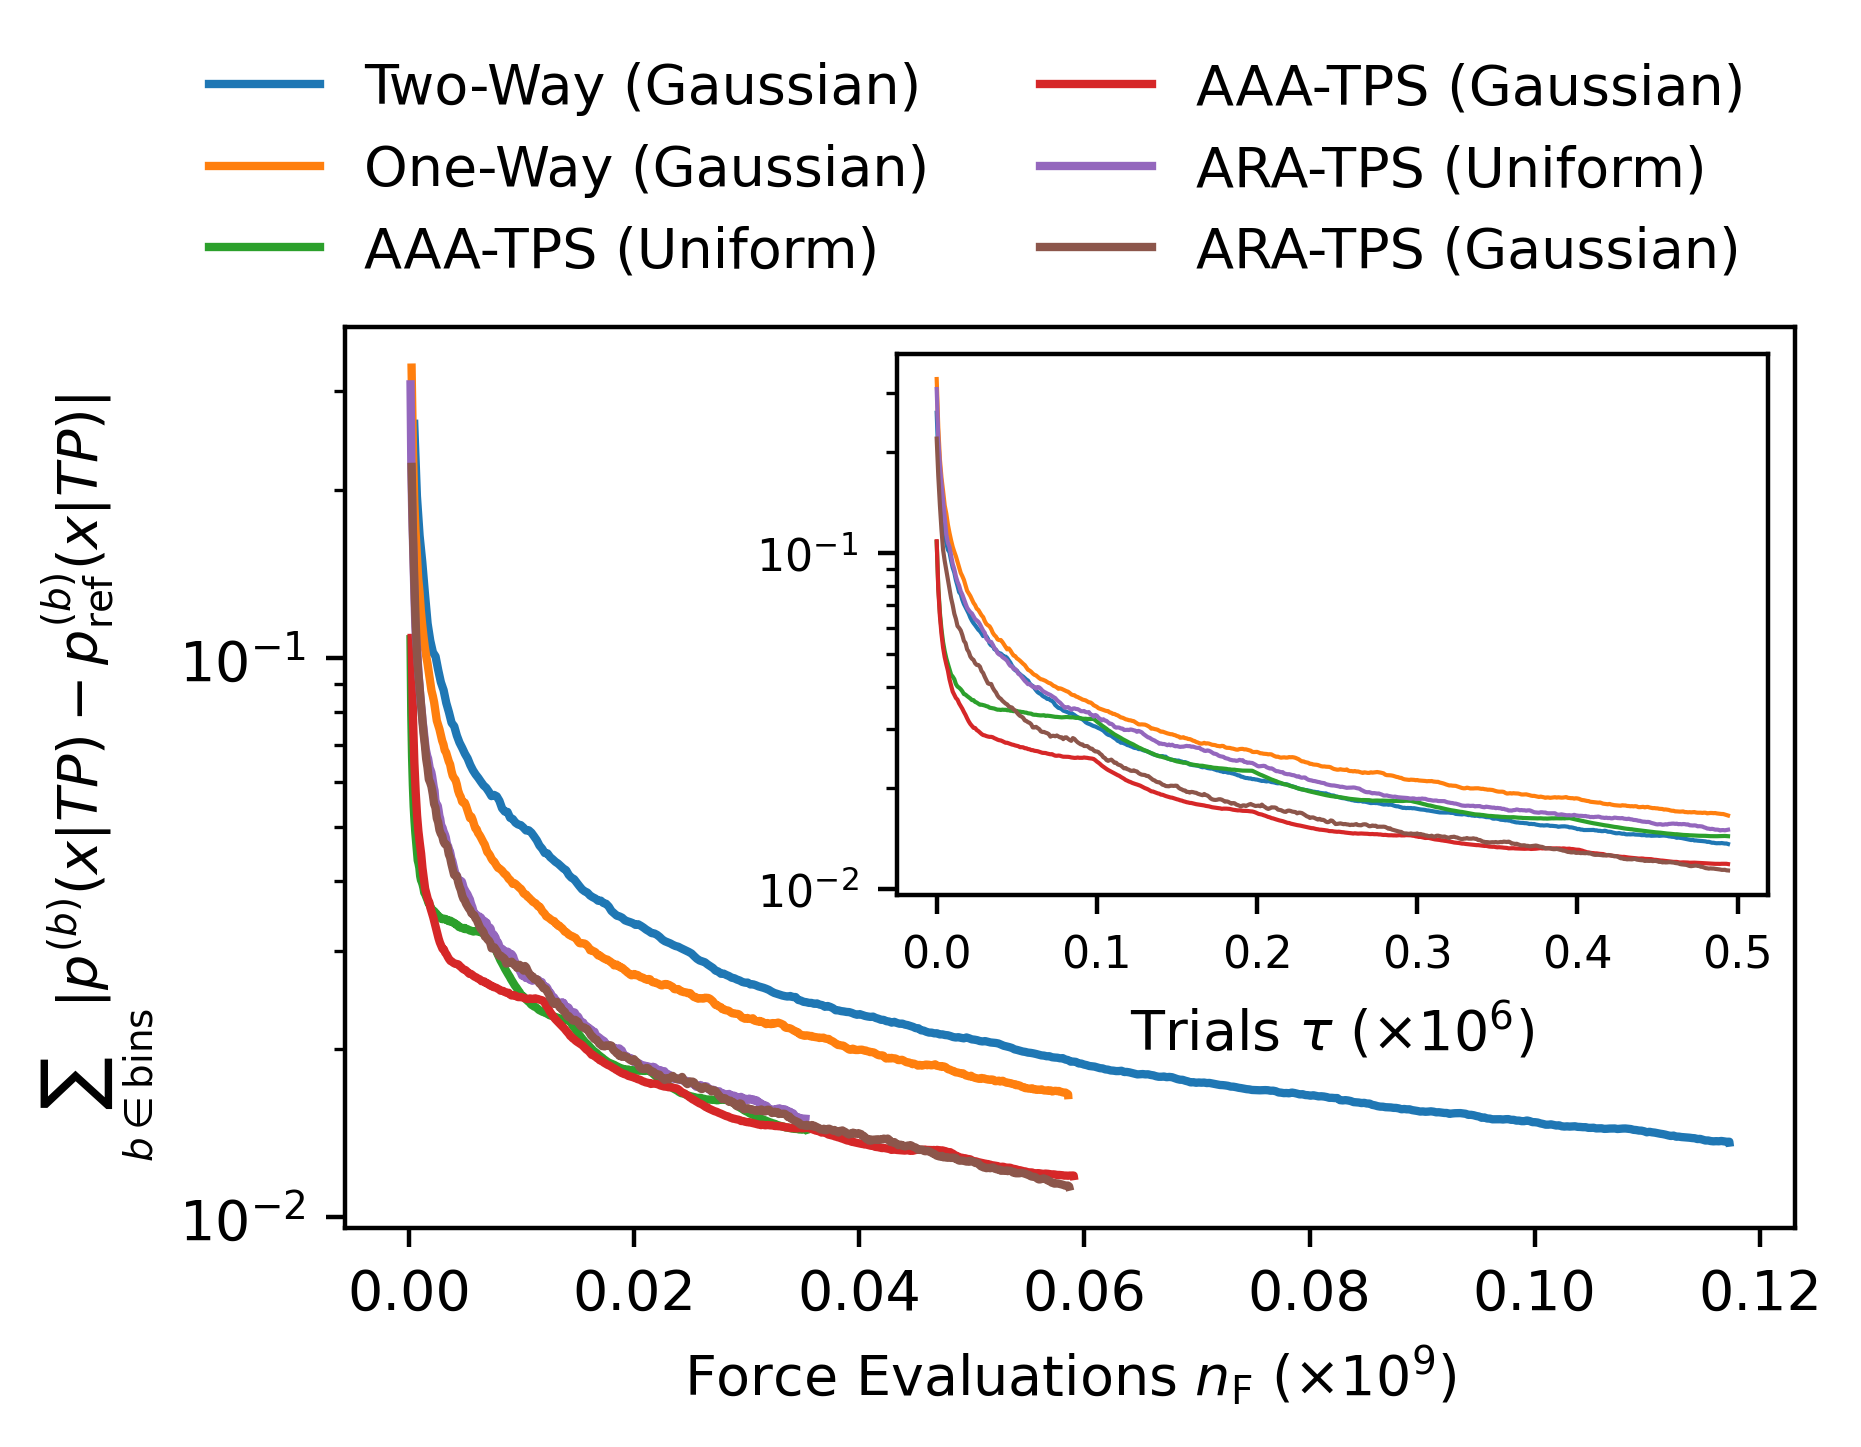

In [20]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, figsize=(12 * 0.39, 7.5 * 0.39), dpi=400)

trials_2w = np.arange(0, len(abs_diff_sums_2w))*traj_step
trials_1w = np.arange(0, len(abs_diff_sums_1w))*traj_step
trials_ARA_TPS_Unif = np.arange(0, len(abs_diff_sums_ARA_TPS_Unif))*traj_step
trials_ARA_TPS_Gaus = np.arange(0, len(abs_diff_sums_ARA_TPS_Gaus))*traj_step
trials_AAA_TPS_Unif = np.arange(0, len(abs_diff_sums_AAA_TPS_Unif))*traj_step
trials_AAA_TPS_Gaus = np.arange(0, len(abs_diff_sums_AAA_TPS_Gaus))*traj_step

feval_2w = trials_2w*per_tr_force_eval_2w.mean()
feval_1w = trials_1w*per_tr_force_eval_1w.mean()
feval_AAA_TPS_Unif = trials_AAA_TPS_Unif*per_tr_force_eval_AAA_TPS_Unif.mean()
feval_AAA_TPS_Gaus = trials_AAA_TPS_Gaus*per_tr_force_eval_AAA_TPS_Gaus.mean()

ax.plot(chunked_tot_force_eval_2w[1:]/1e9, abs_diff_sums_2w[::]/Hist_ref_avg.sum(), ls="-", label="Two-Way (Gaussian)")
ax.plot(chunked_tot_force_eval_1w[1:]/1e9, abs_diff_sums_1w[::]/Hist_ref_avg.sum(), ls="-", label="One-Way (Gaussian)")
ax.plot(chunked_tot_force_eval_AAA_TPS_Unif[1:]/1e9, abs_diff_sums_AAA_TPS_Unif_resampled[::]/Hist_ref_avg.sum(), ls="-", label=r"AAA-TPS (Uniform)")
ax.plot(chunked_tot_force_eval_AAA_TPS_Gaus[1:]/1e9, abs_diff_sums_AAA_TPS_Gaus_resampled[::]/Hist_ref_avg.sum(), ls="-", label=r"AAA-TPS (Gaussian)")
ax.plot(chunked_tot_force_eval_ARA_TPS_Unif[1:]/1e9, abs_diff_sums_ARA_TPS_Unif[::]/Hist_ref_avg.sum(), ls="-", label=r"ARA-TPS (Uniform)")
ax.plot(chunked_tot_force_eval_ARA_TPS_Gaus[1:]/1e9, abs_diff_sums_ARA_TPS_Gaus[::]/Hist_ref_avg.sum(), ls="-", label=r"ARA-TPS (Gaussian)")
ax.set_yscale("log")
ax.set_xlabel(r"Force Evaluations $n_\text{F}$ ($\times 10^9$)")
ax.set_ylabel(r"$\sum_{b\in\text{bins}} |p^{(b)}(x|TP) - p^{(b)}_{\text{ref}}(x|TP)|$")
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.35), frameon=False, ncol=2)

ax_inset = inset_axes(ax, width="60%", height="60%", loc='upper right', bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax.transAxes)  # relative size

ax_inset.plot(trials_2w/1e6, abs_diff_sums_2w[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.plot(trials_1w/1e6, abs_diff_sums_1w[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.plot(trials_AAA_TPS_Unif/1e6, abs_diff_sums_AAA_TPS_Unif_resampled[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.plot(trials_AAA_TPS_Gaus/1e6, abs_diff_sums_AAA_TPS_Gaus_resampled[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.plot(trials_ARA_TPS_Unif/1e6, abs_diff_sums_ARA_TPS_Unif[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.plot(trials_ARA_TPS_Gaus/1e6, abs_diff_sums_ARA_TPS_Gaus[::]/Hist_ref_avg.sum(), lw=.75, ls="-")
ax_inset.set_yscale("log")
ax_inset.set_xlabel(r"Trials $\tau$ ($\times 10^6$)")
ax_inset.tick_params(labelsize=8)

plt.show()